In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
%cd drive/MyDrive/mSHIFT_SHeS/FoodDB\ matches/Publication\ data\ and\ notebooks

/content/drive/MyDrive/mSHIFT_SHeS/FoodDB matches/Publication data and notebooks


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import dill
import time
import importlib

In [4]:
# impact data per 100g
df_impacts = pd.read_parquet("df_impacts_per_100g_1902.parquet")
# Full data of matched items including number of matches from each year of foodDB, Open food facts, recipeDB.
ndb_data = pd.read_csv('NDB_matching_data_FINAL.csv')
# SheS 2021 diet data - used for adding two items that have different desritpions
diet_data = pd.read_parquet('diet_data_SHeS_2021.parquet')

In [5]:
# Number of NDB food items with unique descriptions
len(ndb_data['Local description'].unique())

3074

In [ ]:
# Number of food items with unique food code
len(ndb_data['Food composition record ID'].unique())

2434

In [8]:
# Identify food numbers in the diet data that are not available in the NDB data
for i in diet_data['FoodNumber'].unique():
  if i not in ndb_data['Food composition record ID'].unique():
    print(diet_data[diet_data['FoodNumber']==i][['FoodNumber', 'FoodDescription']].head(1))


      FoodNumber FoodDescription
1823       10966        Oat milk
       FoodNumber                      FoodDescription
30220         356  Savoury pastry (e.g. cheese pastry)


In [9]:
# Food groups that were excluded from the matching, inclduing toddler foods and nutritional supplements
food_groups_exclude = ["CALCIUM ONLY OR WITH VITAMIN D", "OTHER NUTRIENT SUPPLEMENTS", "SINGLE VITS OR MINS NOT Folic acid, Fe, Ca, Vit C", "VITAMINS AND MINERALS (INCL MULTIVITS & MINERALS)",
                       "VITAMINS (TWO OR MORE INCL MULTIVITS) NO MINERALS", "MINERALS (TWO OR MORE INCL MULTIVITS & MINERALS)", "EVENING PRIMROSE OIL AND OTHER PLANT OILS", "MULTIVITAMIN AND/OR MINERALS WITH OMEGA 3",
                       "COD LIVER OIL AND OTHER FISH OILS (INCL VIT A,D,E)",
                       "NON-NUTRIENT SUPPLEMENTS (INCL HERBAL)",
                       "FOLIC ACID",
                       "IRON ONLY OR WITH VITAMIN C",
                       "VITAMIN C ONLY",
                       "NUTRITION POWDERS AND DRINKS",
                       "INFANT FORMULA",
                       "COMMERCIAL TODDLERS FOODS",
                       "COMMERCIAL TODDLERS DRINKS"]

In [10]:
supplement_toddler_food_items = ndb_data[ndb_data['NDNS Food group'].isin(food_groups_exclude)]['Local description'].unique()

In [11]:
len(ndb_data) - len(supplement_toddler_food_items)

2954

In [12]:
# Number of unqiue food codes after excluding the supplements
len(ndb_data[~ndb_data['Local description'].isin(supplement_toddler_food_items)]['Food composition record ID'].unique())

2311

In [13]:
ndb_unmatched_items = []
for item in ndb_data[~ndb_data['Local description'].isin(supplement_toddler_food_items)]['Local description'].unique():
  if item not in df_impacts.index:
    ndb_unmatched_items.append(item)

In [14]:
len(ndb_unmatched_items)

52

In [15]:
manually_matched_items = ['Savoury pastry (e.g. cheese pastry)', 'Oat milk']

In [44]:
# Taking the output of diet_data[diet_data['median_GHG'].isnull()]['FoodDescription'].unique() and removing Oat mlk and Savoury cheese pasty as these items were mappined to other items with impact data

missing_impact_data = ['Mixed nuts, unsalted',
       'Pea and cheese curry (e.g. matar paneer)',
       'Toddler cereal bar (e.g. Organix carrot cake cereal bar)',
       'Bamboo shoots', 'Turmeric', 'Boiled egg, yolk only',
       'Cook-in-sauce, chilli with pulses (e.g. Uncle Bens)',
       'Sweet and sour chicken, ready meal, with rice, reduced fat',
       'Prawn stir fry (prawns and vegetables)', 'Egg curry',
       'Chewing gum, not sugar free', 'Dextrins (maltodextrin)',
       'Finecut salad (e.g. including lettuce, pepper, carrot, sweetcorn, cabbage type) with a cream-based/mayonnaise type dress',
       'Skate, grilled or oven baked',
       'Chicken curry, ready meal, with rice, reduced fat',
       'Whiting in breadcrumb, fried', 'Whiting, grilled or oven baked',
       'Cardamom', 'Vegetarian sausage, cheese based',
       'Boiled egg, white only', 'Lo Salt',
       'Instant cappuccino powder, no sugar', 'Kheema naan', 'Nutmeg',
       'KFC tower burger', 'Low-protein pasta (e.g. Loprofin)', 'Saffron',
       'Mustard cress, raw',
       'Toddler corn snacks (e.g. organix carrot sticks and tomato stars)',
       'Game pie (e.g. venison, rabbit, pheasant)',
       'Meal replacement bar (e.g. Slimfast)']

In [45]:
len(missing_impact_data)

31

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(missing_impact_data)])/len(diet_data)

0.002006694464319492

In [47]:
# Output of diet_data[diet_data['median_price_sim'].isnull()]['FoodDescription'].unique()

missing_price_data = ['Bagel, wholemeal (brown)',
       'Cheese and ham sandwich with white/malted bread',
       'Ham sandwich with wholemeal/oatmeal bread',
       'Cheese sandwich with mayo with wholemeal/oatmeal bread',
       'Bagel, white', 'Milk 1% fat', 'Avocado', 'Pitta bread, white',
       'Strawberry tarlets, with cream', 'Duck egg', 'Crumpet / pikelet',
       'English style bread muffin, white',
       'Pitta bread, wholemeal (brown)',
       'Chicken and bacon sandwich with wholemeal/oatmeal bread',
       'Chicken and ham sandwich with mayo with white/malted bread',
       'Dried strawberries',
       'Egg mayo sandwich with wholemeal/oatmeal bread',
       'Cheese sandwich with white/malted bread', 'Nectarine',
       'Chocolate mini roll', 'Bacon sandwich with white/malted bread',
       'Tomato based pasta sauce, home made',
       'Ham sandwich with white/malted bread',
       'Tuna mayo & cucumber/sweetcorn sandwich with wholemeal/oatmeal bread',
       'Oat milk', 'Ham salad sandwich with white/malted bread',
       'Pasta with vegetables in a cream/cheese-based sauce',
       'Fruit pie, slice from large pie, double crust',
       'Tuna mayo sandwich with white/malted bread',
       'Promax protein meal bar', 'Bagel, seeded',
       'High-fibre therapeutic drink (e.g. Fybogel), sachets',
       'Potato farl/cake',
       'Chicken salad sandwich with white/malted bread',
       'Cheese sandwich with wholemeal/oatmeal bread', 'Cheese scone',
       'Cheese salad sandwich with white/malted bread',
       'Beef sandwich with wholemeal/oatmeal bread',
       'Fruit bars, no added sugar (e.g. nakd bars)',
       'Pea and cheese curry (e.g. matar paneer)', 'Green pepper, cooked',
       'Toddler cereal bar (e.g. Organix carrot cake cereal bar)',
       'Low-fat macaroni cheese, ready meal',
       'Ham salad sandwich with wholemeal/oatmeal bread',
       'Fruit cake, reduced fat', 'Chicken and bacon wrap',
       "Ploughman's sandwich with wholemeal/oatmeal bread",
       'Cheese on toast with white/malted bread',
       'Corned beef sandwich with white/malted bread', 'Turmeric',
       'Chicken in a tomato/BBQ sauce with potato wedges, ready meal, reduced fat',
       'Beef bolognese sauce, home made',
       'Spicy/sweet chilli chicken wrap',
       'Chicken mayo sandwich with white/malted bread',
       'White fish in a cheese sauce (with or without vegetables)',
       'Chicken salad sandwich with wholemeal/oatmeal bread',
       'Potato salad, with reduced fat mayonnaise/salad cream',
       'Chapati, wholemeal (brown), without oil, homemade',
       'Chapati, white, shop-bought',
       'Mixed salad vegetables and leaves, with a cream-based/mayonnaise type dressing',
       'Sandwich thins, wholemeal (brown)',
       'Spring greens (cabbage), cooked',
       'Cheese on toast with wholemeal/oatmeal bread', 'Stewed apple',
       'Cocoa Mass', 'Doughnut filled with jam (with or without glaze)',
       'Cheese salad sandwich with wholemeal/oatmeal bread',
       'Scotch pancake/drop scone', 'Tuna and sweetcorn wrap',
       'Cheese and ham sandwich with wholemeal/oatmeal bread',
       'Chicken and bacon sandwich with white/malted bread',
       'Chicken mayo sandwich with wholemeal/oatmeal bread',
       'Ring doughnut, without icing',
       'Tuna and cucumber sub roll/baguette',
       'Meat risotto (e.g. beef/ham)',
       'Tuna mayo sandwich with wholemeal/oatmeal bread',
       'Meat feast sub roll/baguette', 'Sharon fruit', 'Carrots, fried',
       'Chocolate Krispie cake', 'Fruit pie, individual',
       'Egg mayo sandwich with white/malted bread', 'Haslet',
       'Tuna mayo & cucumber/sweetcorn sandwich with white/malted bread',
       'Salmon and cucumber sandwich with wholemeal/oatmeal bread',
       'Venison sausage', 'Pate sandwich with white/malted bread',
       'Sausage and egg in a bun/muffin (e.g. Bacon and egg McMuffin)',
       'Marjoram', 'Boiled egg, yolk only',
       'Cook-in-sauce, chilli with pulses (e.g. Uncle Bens)',
       'BLT sandwich with wholemeal/oatmeal bread', 'Welsh cake',
       'Chinese meat bun', 'Ring doughnut, with icing',
       'Ham and cheese sub roll/baguette',
       'Chicken and bacon sub roll/baguette',
       'Sweet and sour chicken, ready meal, with rice, reduced fat',
       'Chocolate and nut brownie', 'Swiss roll sponge, with fresh cream',
       'Mr whippy style ice cream',
       'Instant potato (e.g. Smash), made up with milk',
       'Chapati, wholemeal (brown), shop-bought',
       'Cheese sandwich with mayo with white/malted bread',
       'Meat sandwich paste (e.g. chicken, beef)',
       'Prawn stir fry (prawns and vegetables)', 'Lamb biryani',
       'Stuffed marrow', 'Bread roll, cheese topped',
       'Smoked salmon and cream cheese sandwich with wholemeal/oatmeal bread',
       'Rhubarb, stewed with sugar',
       'Chicken salad sandwich with mayo with white/malted bread',
       'Almond slices (e.g. Mr Kipling)', "McDonald's Mcflurry",
       'Potato farl/cake, fried',
       'Chicken salad sandwich with mayo with wholemeal/oatmeal bread',
       'Doughnut filled with custard',
       'Bacon sandwich with wholemeal/oatmeal bread',
       'Beef chow mein, stir fry (with noodles)',
       'BBQ Southern fried chicken wrap',
       'Corned beef sandwich with wholemeal/oatmeal bread',
       'Cake slice, reduced fat (e.g. Weight Watchers)', 'Paprika',
       'Fish pizza (e.g. with anchovies)', 'Vegetable casserole',
       'Cassava, cooked', 'Orange peel/zest', 'Avocado puree',
       'English style bread muffin, wholemeal (brown)',
       'Flapjack, Reduced fat', 'Egg curry', 'Cream bun with jam',
       'Chicken/turkey bolognese sauce, homemade',
       'Fruit pie, fried (e.g. McDonalds apple pie)',
       'Prawn mayo sandwich with wholemeal/oatmeal bread',
       'Ham salad sandwich with mayo with wholemeal/oatmeal bread',
       'Plain popcorn', 'Duck with hoisin sauce wrap',
       'Cup cake/fairy cake, without icing', 'Dextrins (maltodextrin)',
       'Pate sandwich with wholemeal/oatmeal bread', 'Wheat bran',
       'Sausage and egg in a bun/muffin (e.g. Sausage and egg McMuffin)',
       'Finecut salad (e.g. including lettuce, pepper, carrot, sweetcorn, cabbage type) with a cream-based/mayonnaise type dress',
       'McDonalds/Burger King dips and sauces',
       'Vegetable curry, with lentils',
       'Chicken sandwich with wholemeal/oatmeal bread',
       'Pork Chow mein, stir fry (with noodles)',
       'Beef sandwich with white/malted bread',
       'Chicken sandwich with white/malted bread',
       'BLT sandwich with white/malted bread', 'Chapati, white',
       'Hot dog/frankfurter with sauce in a bun',
       'Ham salad sandwich with mayo with white/malted bread',
       'Mushroom curry / mushroom bhaji', 'Tabbouleh',
       'Boiled potato puree', 'Savoury pastry (e.g. cheese pastry)',
       'Skate, grilled or oven baked', 'Pineapple upside down cake',
       'Oxtail', 'Cheesecake, reduced fat', 'Meatloaf',
       'Mocha made with skimmed milk (skinny mocha)',
       'Spring greens (cabbage)',
       'Hot chocolate, made with milk, topped with cream', 'Belgian bun',
       'Ham and cheese slice/pie (with or without vegetable)',
       'Chicken curry, ready meal, with rice, reduced fat',
       'Chicken and bacon sandwich with mayo with wholemeal/oatmeal bread',
       'Cheese & jalapeno bread/roll',
       'Instant potato (e.g. Smash), made up with water',
       'Lower calorie pizza (e.g. Delight, Leggera), vegetarian, takeaway/restaurant',
       'Welsh rarebit, on wholemeal (brown) toast',
       'Lamb kebab with minced lamb and herbs',
       'Prawn mayo sandwich with white/malted bread', 'Almond croissants',
       'Coconut cake', 'Whiting in breadcrumb, fried', 'Dried yeast',
       'Fruit gateau, with cream (e.g. strawberry gateaux)',
       'Whiting, grilled or oven baked',
       'Seafood pasta in a cream based sauce',
       'Ham and egg sub roll/baguette', 'Beef biryani',
       'Flan, fruit; sponge base with fruit',
       'Bacon sandwich with mayo  wholemeal/oatmeal bread',
       'Prawn cocktail wrap',
       'Salmon and cucumber sandwich with white/malted bread',
       'Vegetarian sausage, cheese based', 'Honeycomb', 'Coconut tart',
       'Boiled egg, white only',
       'Chocolate cup cake/fairy cake, without icing', 'Lo Salt',
       'Instant cappuccino powder, no sugar', 'Kheema naan',
       'Baked alaska', 'Pea curry (e.g. matar curry)', 'KFC tower burger',
       'Low-protein pasta (e.g. Loprofin)', 'Waldorf salad',
       'Pea and potato curry (e.g. aloo matar)', 'Saffron',
       'Roast/stewed rabbit', 'Mustard cress, raw',
       'Toddler corn snacks (e.g. organix carrot sticks and tomato stars)',
       'Seafood pasta in a tomato based sauce',
       'Croissants, plain, reduced fat',
       "Milkshake, thick, with ice cream, purchased (e.g. McDonald's, Wimpy)",
       'Game pie (e.g. venison, rabbit, pheasant)', 'Stuffed jalapenos',
       'Chicken and ham sandwich with mayo with wholemeal/oatmeal bread',
       'Vegetable goulash', 'Chapati, wholemeal (brown)',
       'Welsh rarebit, on white toast',
       'Meal replacement bar (e.g. Slimfast)']

In [48]:
missing_price_data.remove("Oat milk")
missing_price_data.remove("Savoury pastry (e.g. cheese pastry)")

In [49]:
len(diet_data[diet_data['FoodDescription'].isin(missing_price_data)])/len(diet_data)

0.028694086008240607

In [50]:
#manual match for oat milk and cheese pastry
(len(diet_data[diet_data['median_GHG'].isnull()]['FoodDescription'].unique())-2)/len(diet_data['FoodDescription'].unique())

0.012943632567849687

In [52]:
df_impacts_final = df_impacts.loc[~df_impacts.index.isin(supplement_toddler_food_items), :]

In [ ]:
df_impacts_final.to_csv('NDB_foodDB_matched_data_final.csv')

# Analyse the data

In [ ]:
df_impacts_final = pd.read_csv('NDB_foodDB_matched_data_final.csv')

## Inclusion and exclusion counts

In [54]:
!ls

 Count_distributions.png	     df_inclusion_total.csv
 COunt_distributions.png	     diet_data_SHeS_2021.parquet
 df_impacts_per_100g_1902.parquet   'Identify missing matches.ipynb'
 df_inclusion_counts_FM.parquet      NDB_foodDB_matched_data_final.csv
 df_inclusion_counts_gpt.parquet     NDB_matching_data_FINAL.csv
 df_inclusion_counts_total.parquet


In [57]:
# Number of matches per NDB item identified by fuzzy matching
df_inclusion_fm = pd.read_parquet('df_inclusion_counts_FM.parquet')
# Number of matches per NDB item identified by GPT-4
df_inclusion_gpt = pd.read_parquet('df_inclusion_counts_gpt.parquet')
# Number of matches identified by both fizzy matching and GPT-4 combined
df_inclusion = pd.read_parquet('df_inclusion_counts_total.parquet')

In [59]:
df_inclusion.median()

,0
count,6.0


In [60]:
df_inclusion_gpt.mean()

,0
count,14.364466


In [61]:
df_inclusion_fm.mean()

,0
count,2.635576


In [62]:
# Total number of items with no match from GPT-4
df_inclusion_gpt[df_inclusion_gpt['count']==0]

,count
Banana chips,0
"Banana, baked",0
Banana puree,0
Carrot puree,0
"Clams, boiled",0
...,...
Special fried rice,0
Omelette with cheese and potato,0
Toffee popcorn,0
Yoghurt coated dried fruit pieces,0


In [63]:
# Total number o fitems with no match from fuzzy matching
df_inclusion_fm[df_inclusion_fm['count']==0]

,count
"Ackee, canned",0
"Animal fat (e.g. beef dripping, chicken fat)",0
Apple chutney,0
"Apple juice drink, ready to drink, no added sugar",0
"Apple juice drink, ready to drink",0
...,...
"Sausage with vegetable mash, ready meal, reduced fat (e.g. Weight Watchers)",0
"Yam, cooked",0
Dried yeast,0
"Yorkshire pudding, shop-bought (e.g. Aunt Bessie)",0


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:

plt.rcParams["font.family"] = 'serif'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.formatter.use_mathtext"] = True

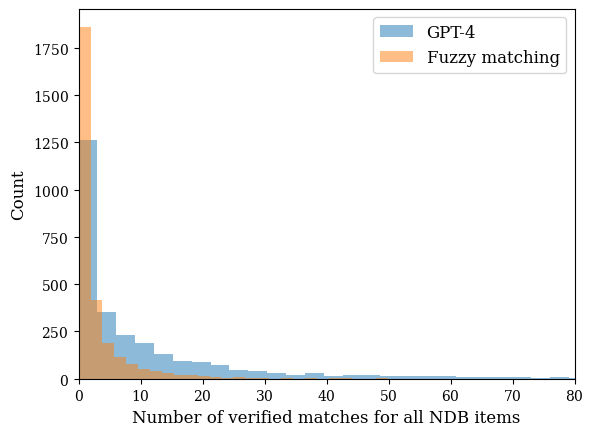

In [66]:
plt.hist(df_inclusion_gpt['count'], bins=150, alpha=0.5, label='GPT-4')
plt.hist(df_inclusion_fm['count'], bins=50, alpha=0.5, label='Fuzzy matching')

# sns.kdeplot(df_inclusion_gpt['count'], color='red', alpha=0.5, fill=True)
# sns.kdeplot(df_inclusion_fm['count'], color='blue', alpha=0.5, fill=True)
plt.legend(fontsize=12)
plt.xlabel("Number of verified matches for all NDB items", fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xlim(0, 80)
plt.savefig("Count_distributions.png", dpi=300)
plt.show()

## Identify number of mathces found in both foodDB, open food facts and recipeDB

In [68]:
foodDB_filter = (df_impacts_final['num_prods_fooddb_2022']==0) & (df_impacts_final['num_prods_fooddb_2021']==0) & (df_impacts_final['num_prods_fooddb_2019']==0)
off_filter = (df_impacts_final['num_prods_open_food_facts']==0)
recipeDB_filter = (df_impacts_final['num_prods_recipeDB']==0)

In [71]:
df_impacts_final[foodDB_filter & off_filter & recipeDB_filter].index.unique()


Index(['Water (from tap, including hot water, filtered water)'], dtype='object', name='ndb_cat')

In [75]:
df_impacts_final[foodDB_filter & ~off_filter & ~recipeDB_filter]

,tot_num_products,num_prods_fooddb_2022,num_prods_fooddb_2021,num_prods_fooddb_2019,num_prods_open_food_facts,num_prods_recipeDB,sd_mean_GHG,sd_mean_Land,sd_mean_WatScar,sd_mean_Eut,...,sd_price_2019,sd_median_size_2019,sd_median_price_2019,mean_price_2019,mean_size_2019,median_price_2019,median_size_2019,mean_price_sim,median_price_sim,sd_price_sim
ndb_cat,,,,,,,,,,,,,,,,,,,,,
"Hot chocolate, made with milk",6.0,0.0,0.0,0.0,1.0,5.0,1.231844,0.388252,253.732591,0.941651,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pulled pork (no sauce),2.0,0.0,0.0,0.0,1.0,1.0,0.263896,0.512808,2954.008177,3.494198,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.78117,101.78117,0.0
Waldorf salad,9.0,0.0,0.0,0.0,1.0,8.0,0.054309,0.085677,581.129346,0.114006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
White fish in a cheese sauce (with or without vegetables),3.0,0.0,0.0,0.0,1.0,2.0,0.155401,0.188995,971.898888,2.360965,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
df_impacts_final[foodDB_filter & ~off_filter & recipeDB_filter]

,tot_num_products,num_prods_fooddb_2022,num_prods_fooddb_2021,num_prods_fooddb_2019,num_prods_open_food_facts,num_prods_recipeDB,sd_mean_GHG,sd_mean_Land,sd_mean_WatScar,sd_mean_Eut,...,sd_price_2019,sd_median_size_2019,sd_median_price_2019,mean_price_2019,mean_size_2019,median_price_2019,median_size_2019,mean_price_sim,median_price_sim,sd_price_sim
ndb_cat,,,,,,,,,,,,,,,,,,,,,
Alcoholic soft drink (e.g. Crabbies ginger beer),1.0,0.0,0.0,0.0,1.0,0.0,1.337804,0.182081,20645.082400,19.411830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.606061,60.606061,0.0
"Carrots, fried",1.0,0.0,0.0,0.0,1.0,0.0,0.001458,0.001390,6.494910,0.018831,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Cinnamon, ground",1.0,0.0,0.0,0.0,1.0,0.0,0.022473,0.166241,674.729382,0.281648,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,236.842105,236.842105,0.0
Cocoa Mass,1.0,0.0,0.0,0.0,1.0,0.0,5.319835,1.522790,112.249554,3.996958,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Dill, fresh",1.0,0.0,0.0,0.0,1.0,0.0,0.010930,0.033095,2625.498828,0.012340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300.000000,300.000000,0.0
Dragon fruit,1.0,0.0,0.0,0.0,1.0,0.0,0.032462,0.034970,1383.516114,0.548540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dried yeast,5.0,0.0,0.0,0.0,5.0,0.0,0.025202,0.017811,237.297233,0.031615,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Flapjack, Reduced fat",6.0,0.0,0.0,0.0,6.0,0.0,0.016958,0.065352,490.258034,0.135482,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gelatin,2.0,0.0,0.0,0.0,2.0,0.0,0.348445,0.974508,3914.834744,4.669712,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
df_impacts_final[foodDB_filter & off_filter & ~recipeDB_filter]

,tot_num_products,num_prods_fooddb_2022,num_prods_fooddb_2021,num_prods_fooddb_2019,num_prods_open_food_facts,num_prods_recipeDB,sd_mean_GHG,sd_mean_Land,sd_mean_WatScar,sd_mean_Eut,...,sd_price_2019,sd_median_size_2019,sd_median_price_2019,mean_price_2019,mean_size_2019,median_price_2019,median_size_2019,mean_price_sim,median_price_sim,sd_price_sim
ndb_cat,,,,,,,,,,,,,,,,,,,,,
"Alcopop, not spirit based (e.g. Hooch, WKD)",1.0,0.0,0.0,0.0,0.0,1.0,0.010685,0.048050,949.645948,0.107483,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.454545,45.454545,0.0
Bacon burger (no bun),2.0,0.0,0.0,0.0,0.0,2.0,0.126581,0.232870,839.236326,0.818697,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Baked alaska,6.0,0.0,0.0,0.0,0.0,6.0,0.053658,0.107650,320.889605,0.276674,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Beef and vegetable stew,4.0,0.0,0.0,0.0,0.0,4.0,0.273609,2.239035,897.885446,19.210400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Beef biryani,4.0,0.0,0.0,0.0,0.0,4.0,0.858293,4.265038,820.829895,0.835248,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Welsh rarebit, on wholemeal (brown) toast",5.0,0.0,0.0,0.0,0.0,5.0,0.397915,0.751724,1558.668264,0.588445,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
West Indian dumplings,1.0,0.0,0.0,0.0,0.0,1.0,0.077012,0.559476,3895.265401,0.855791,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wholemeal pastry (savoury),1.0,0.0,0.0,0.0,0.0,1.0,0.002230,0.024580,209.075359,0.066304,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
